In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


### STEP 1: Load the dataset

In [4]:
df = pd.read_csv("C:\\Users\\Sakshu\\Downloads\\archive\\wine_classification.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


First 5 rows:
   Class  Alcohol  Malic acid   Ash  Alcalinity of ash   Magnesium  \
0      1    14.23        1.71  2.43                15.6        127   
1      1    13.20        1.78  2.14                11.2        100   
2      1    13.16        2.36  2.67                18.6        101   
3      1    14.37        1.95  2.50                16.8        113   
4      1    13.24        2.59  2.87                21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315  Proline  
0             5.64  1.04         3.92     1065  
1             4.38  1.05         3.40   

### Step 2: Check Missing values

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Class                   0
Alcohol                 0
Malic acid              0
Ash                     0
Alcalinity of ash       0
Magnesium               0
Total phenols           0
Flavanoids              0
Nonflavanoid phenols    0
Proanthocyanins         0
Color intensity         0
Hue                     0
OD280/OD315             0
Proline                 0
dtype: int64


### STEP 3: Separate features and target

In [12]:
y = df['Class']

# Remove target column
X = df.drop('Class', axis=1)

print("\nNumber of Features:")
print(X.shape[1])




Number of Features:
13


### STEP 4: Standardize the data

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Data:")
print(X_scaled[:5])



Standardized Data:
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522  0.80899739
   1.03481896 -0.65956311  1.22488398  0.25171685  0.36217728  1.84791957
   1.01300893]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502  0.56864766
   0.73362894 -0.82071924 -0.54472099 -0.29332133  0.40605066  1.1134493
   0.96524152]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836  0.80899739
   1.21553297 -0.49840699  2.13596773  0.26901965  0.31830389  0.78858745
   1.39514818]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845  2.49144552
   1.46652465 -0.98187536  1.03215473  1.18606801 -0.42754369  1.18407144
   2.33457383]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515  0.80899739
   0.66335127  0.22679555  0.40140444 -0.31927553  0.36217728  0.44960118
  -0.03787401]]


### STEP 5: Apply PCA

In [14]:
# Reduce 13 features to 2 components

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA Transformed Data:")
print(X_pca[:5])


PCA Transformed Data:
[[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


### STEP 6: Explain variance

In [15]:
explained_variance = pca.explained_variance_ratio_

print("\nVariance Explained by Each Component:")

for i, variance in enumerate(explained_variance):
    print(
        "PC", i + 1,
        "=",
        round(variance * 100, 2),
        "%"
    )



Variance Explained by Each Component:
PC 1 = 36.2 %
PC 2 = 19.21 %


### STEP 7: Total variance retained

In [16]:
total_variance = sum(explained_variance) * 100

print("\nTotal Variance Retained:")
print(round(total_variance, 2), "%")



Total Variance Retained:
55.41 %


### STEP 8: PCA Visualization

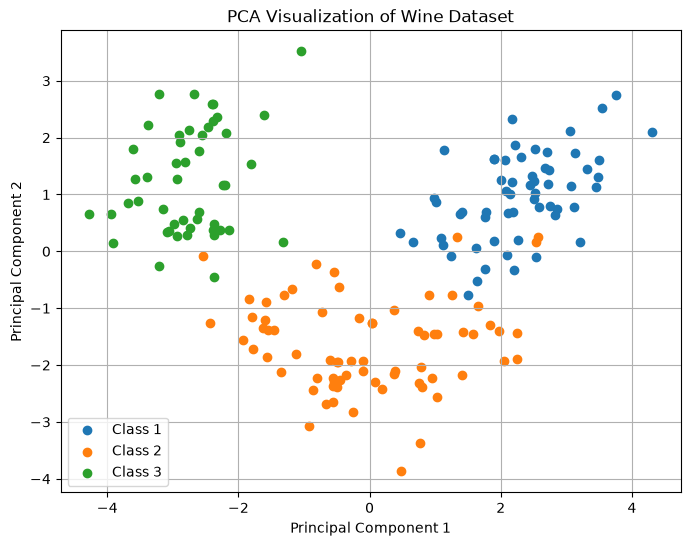

In [17]:

plt.figure(figsize=(8, 6))

for wine_class in sorted(y.unique()):

    plt.scatter(
        X_pca[y == wine_class, 0],
        X_pca[y == wine_class, 1],
        label=f"Class {wine_class}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Wine Dataset")

plt.legend()
plt.grid()

plt.show()


### STEP 9: PCA with all components

In [18]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

cumulative_variance = (
    pca_full.explained_variance_ratio_.cumsum()
)

print("\nCumulative Variance:")
print(cumulative_variance)



Cumulative Variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


### STEP 10: PCA Cumulative variance graph

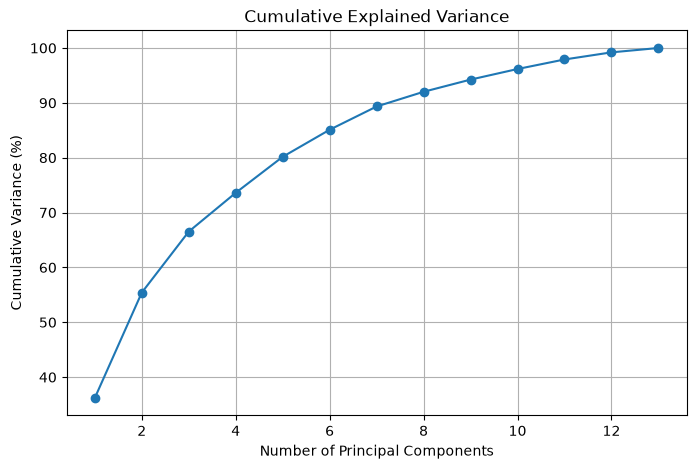

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance (%)")
plt.title("Cumulative Explained Variance")

plt.grid()

plt.show()


### STEP 11: Variance bar chart 

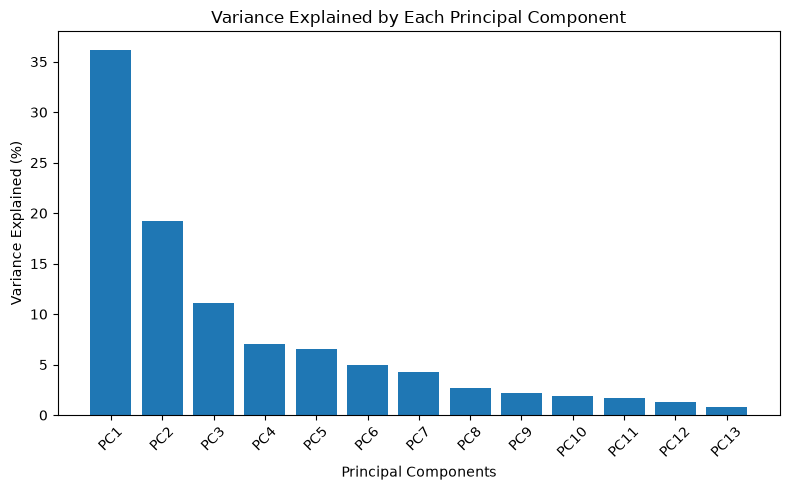

In [20]:

plt.figure(figsize=(8, 5))

components = [
    f"PC{i+1}"
    for i in range(len(pca_full.explained_variance_ratio_))
]

plt.bar(
    components,
    pca_full.explained_variance_ratio_ * 100
)

plt.xlabel("Principal Components")
plt.ylabel("Variance Explained (%)")
plt.title("Variance Explained by Each Principal Component")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()